In [1]:
import numpy as np
from osgeo import gdal
import os
from PIL import Image


data_dir = "./copernicus-s1/subset_2_of_subset_1_of_S1C_IW_GRDH_1SDV_Orb_EC_Cal.data"
band_file = os.path.join(data_dir, "Sigma0_VH_db.img")

ds = gdal.Open(band_file)
band = ds.GetRasterBand(1)
sigma0_db = band.ReadAsArray().astype(np.float32)

# ── 실제 NoData 값 확인 ──────────────────────────────────
snap_nodata = band.GetNoDataValue()
print(f"SNAP 설정 NoData 값: {snap_nodata}")

# ── 극단값 분포 확인 ─────────────────────────────────────
print(f"\n전체 픽셀 수: {sigma0_db.size:,}")
print(f"NaN 픽셀:     {np.isnan(sigma0_db).sum():,}")
print(f"-inf 픽셀:    {np.isneginf(sigma0_db).sum():,}")
print(f"< -100 픽셀:  {(sigma0_db < -100).sum():,}")
print(f"< -60 픽셀:   {(sigma0_db < -60).sum():,}")
print(f"< -50 픽셀:   {(sigma0_db < -50).sum():,}")
print(f"== 0.0 픽셀:  {(sigma0_db == 0.0).sum():,}")

# ── 하위 1% 값 확인 ─────────────────────────────────────
finite_vals = sigma0_db[np.isfinite(sigma0_db)]
print(f"\n유한값 픽셀: {len(finite_vals):,}")
print(f"하위 0.1%:  {np.percentile(finite_vals, 0.1):.3f} dB")
print(f"하위 1%:    {np.percentile(finite_vals, 1.0):.3f} dB")
print(f"하위 5%:    {np.percentile(finite_vals, 5.0):.3f} dB")
print(f"상위 95%:   {np.percentile(finite_vals, 95.0):.3f} dB")
print(f"상위 99%:   {np.percentile(finite_vals, 99.0):.3f} dB")
print(f"상위 99.9%: {np.percentile(finite_vals, 99.9):.3f} dB")

SNAP 설정 NoData 값: None

전체 픽셀 수: 1,002,001
NaN 픽셀:     0
-inf 픽셀:    0
< -100 픽셀:  0
< -60 픽셀:   0
< -50 픽셀:   0
== 0.0 픽셀:  0

유한값 픽셀: 1,002,001
하위 0.1%:  -36.827 dB
하위 1%:    -34.933 dB
하위 5%:    -33.394 dB
상위 95%:   -14.955 dB
상위 99%:   -11.565 dB
상위 99.9%: -7.663 dB


d:\Project-Sentinel12\.venv_py312\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [2]:
geotransform = ds.GetGeoTransform()
projection = ds.GetProjection()

# ── SNAP NoData 값 자동 읽기 ────────────────────────────
snap_nodata = band.GetNoDataValue()
print(f"SNAP NoData: {snap_nodata}")
print(f"Shape: {sigma0_db.shape}")
print(f"Min: {np.nanmin(sigma0_db):.3f}, Max: {np.nanmax(sigma0_db):.3f}")

# ── NoData 마스크 (강화 버전) ───────────────────────────
nodata_mask = (
    np.isnan(sigma0_db)       |   # NaN
    np.isinf(sigma0_db)       |   # ±inf (-inf: log(0), +inf: 이상값)
    (sigma0_db < -60.0)           # -60dB 미만: 물리적으로 불가능한 VH값
                                  # (VH 실제 최솟값 ≈ -40~-45 dB)
)

# SNAP NoData가 명시적으로 설정된 경우 추가
if snap_nodata is not None:
    nodata_mask |= (sigma0_db == snap_nodata)

print(f"NoData 픽셀: {nodata_mask.sum():,} ({100*nodata_mask.sum()/sigma0_db.size:.2f}%)")

# ── 유효 픽셀만으로 실제 분포 확인 ────────────────────────
valid_vals = sigma0_db[~nodata_mask]
print(f"유효 픽셀 Min: {valid_vals.min():.3f}, Max: {valid_vals.max():.3f}")
print(f"유효 픽셀 Mean: {valid_vals.mean():.3f}, Std: {valid_vals.std():.3f}")


SNAP NoData: None
Shape: (1001, 1001)
Min: -41.943, Max: 10.746
NoData 픽셀: 0 (0.00%)
유효 픽셀 Min: -41.943, Max: 10.746
유효 픽셀 Mean: -27.459, Std: 5.910


In [3]:
# ── dB Clipping ──────────────────────────────────────────
VH_MIN = -35.0
VH_MAX =  -3.0

clipped = np.where(nodata_mask, np.nan, np.clip(sigma0_db, VH_MIN, VH_MAX))

# ── Min-Max 정규화 → [0, 255] ────────────────────────────
normalized = (clipped - VH_MIN) / (VH_MAX - VH_MIN) * 255
normalized = np.where(nodata_mask, 0, normalized)   # NoData → 0 (검정)
uint8_img = np.clip(normalized, 0, 255).astype(np.uint8)


GeoTIFF saved: Sigma0_VH_db_normalized510.tif


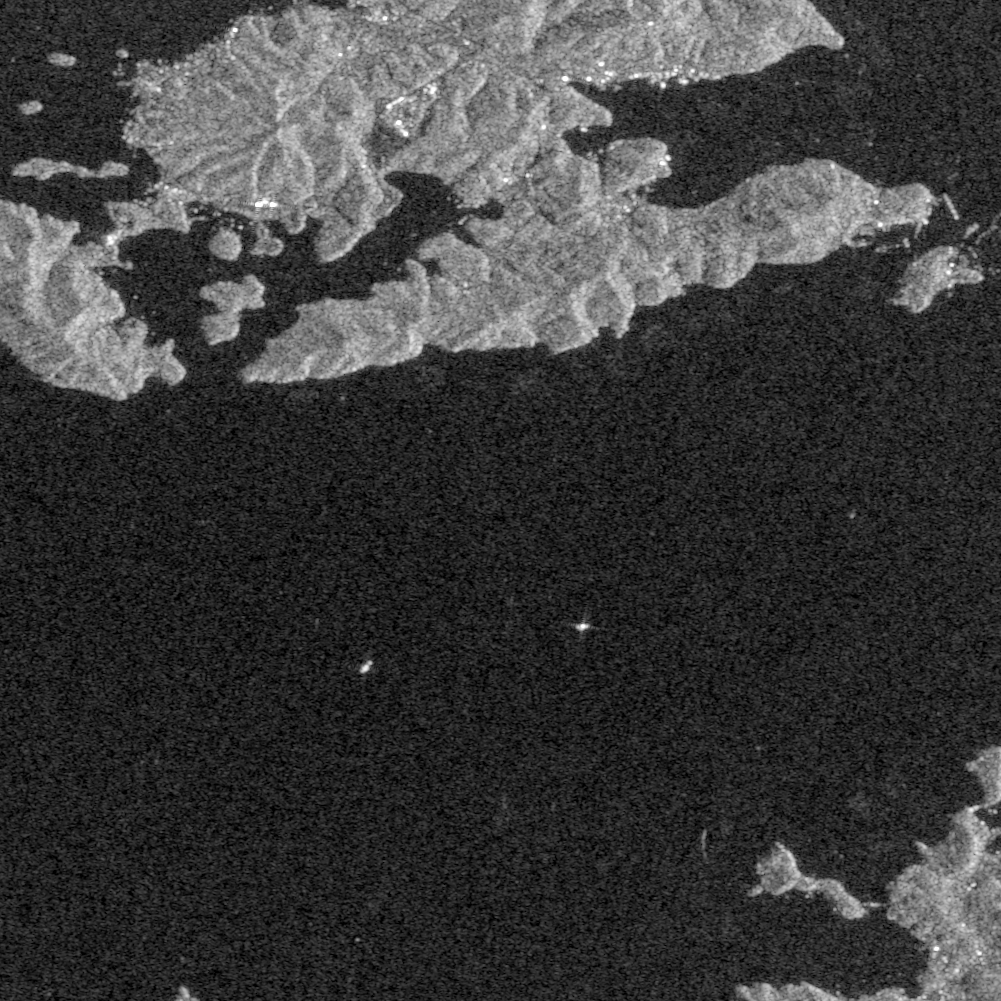

In [ ]:
# ── GeoTIFF 저장 ──────────────────────────────────────────
output_tif = "Sigma0_VH_db_normalized.tif"
driver = gdal.GetDriverByName('GTiff')
h, w = uint8_img.shape
# gdal.GDT_Byte: 
# 8비트 부호 없는 정수(8-bit unsigned integer, 0~255) 데이터 타입을 정의하는 상수
out_ds = driver.Create(output_tif, w, h, 3, gdal.GDT_Byte,
                       options=['COMPRESS=LZW', 'TILED=YES'])
out_ds.SetGeoTransform(geotransform)
out_ds.SetProjection(projection)
for ch in range(1, 4):
    out_ds.GetRasterBand(ch).WriteArray(uint8_img)
    out_ds.GetRasterBand(ch).SetNoDataValue(0)
out_ds.FlushCache()
out_ds.Close()
print(f"GeoTIFF saved: {output_tif}")


# ── JPG 저장 / Display ─────────────────────────────────────
rgb = np.stack([uint8_img]*3, axis=-1)
# Image.fromarray(rgb, mode='RGB').save( "Sigma0_VH_db_normalized.jpg", quality=95)
img = Image.fromarray(rgb, mode='RGB')
img
# print("JPG saved")